# Transformer Protection LSTM Training Pipeline

**Description:** End-to-end training pipeline for a Hybrid Adaptive Transformer Differential Protection scheme using LSTM. This notebook includes data loading, offline training with K-Fold Cross-Validation, metadata analysis, and failure case diagnostics.

##0. Connecting and Mounting to Google Drive

In [ ]:
# Cell: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##Imports & Setup

In [ ]:
import scipy.io
import h5py
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from torch.utils.data import TensorDataset, DataLoader, SubsetRandomSampler
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import json

# Configuration
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")



## 1. Data Loading Utilities
These functions handle the loading of MATLAB `.mat` files, supporting both v7 (standard) and v7.3 (HDF5) formats to ensure compatibility with large datasets.

In [ ]:
def load_matlab_data_complete(filename):
    """Load MATLAB .mat file including all metadata"""
    print(f" Loading: {filename}")

    try:
        data = scipy.io.loadmat(filename, squeeze_me=True, struct_as_record=False)
        print("   ✓ Loaded with scipy.io (MATLAB v7 format)")

        X_LSTM = data['X_LSTM']
        Y_LSTM = data['Y_LSTM']
        metadata = data.get('metadata', None)

        return X_LSTM, Y_LSTM, metadata

    except NotImplementedError:
        print("   ⚠ MATLAB v7.3 detected, using h5py...")

        with h5py.File(filename, 'r') as f:
            X_LSTM = np.array(f['X_LSTM'])
            Y_LSTM = np.array(f['Y_LSTM']).flatten()

            metadata = {}
            print(f"   Debug (h5py): Top-level keys in file: {list(f.keys())}") # Added debug
            if 'metadata' in f:
                meta_group = f['metadata']
                print(f"   Debug (h5py): Keys within 'metadata' group: {list(meta_group.keys())}") # Added debug
                metadata = load_hdf5_group_recursive(f, meta_group) # Pass 'f' and rename for clarity
                print(f"   Debug (h5py): Metadata dictionary keys after load_hdf5_group_recursive: {metadata.keys()}") # Added debug
            else:
                print("   Debug (h5py): 'metadata' key not found in h5py file.") # Added debug

            print("   ✓ Loaded with h5py (MATLAB v7.3 format)")

            return X_LSTM, Y_LSTM, metadata

def load_hdf5_group_recursive(h5_file, group):
    """Recursively load HDF5 group, handling references for strings."""
    result = {}
    for key in group.keys():
        item = group[key]
        if isinstance(item, h5py.Group):
            result[key] = load_hdf5_group_recursive(h5_file, item)
        elif isinstance(item, h5py.Dataset):
            # Check if it's an array of HDF5 references (typical for MATLAB cell arrays of strings)
            if item.dtype == h5py.ref_dtype:
                # Use load_cell_array_h5 to correctly dereference and decode strings
                result[key] = load_cell_array_h5(h5_file, item)
            else:
                # For regular datasets, just load as numpy array
                result[key] = np.array(item)
    return result

def load_batch_dataset(filename):
    """Load raw batch dataset with all fault parameters"""
    print(f"Loading batch dataset: {filename}")

    try:
        mat = scipy.io.loadmat(filename, squeeze_me=True, struct_as_record=False)
        dataset = mat['dataset']

        data_dict = {
            'zone': extract_cell_array(dataset.zone),
            'faultType': extract_cell_array(dataset.faultType),
            'faultResistance': np.array(dataset.faultResistance),
            'inceptionAngle': np.array(dataset.inceptionAngle),
            'inceptionTime': np.array(dataset.inceptionTime),
            'shouldTrip': np.array(dataset.shouldTrip),
            'noiseLevel': np.array(dataset.noiseLevel) if hasattr(dataset, 'noiseLevel') else None,
            'simulationStatus': extract_cell_array(dataset.simulationStatus)
        }

        print("   ✓ Loaded with scipy.io")

    except (NotImplementedError, ValueError):
        print("   ⚠ Using h5py for v7.3 format...")

        with h5py.File(filename, 'r') as f:
            dataset = f['dataset']

            data_dict = {
                'zone': load_cell_array_h5(f, dataset['zone']),
                'faultType': load_cell_array_h5(f, dataset['faultType']),
                'faultResistance': np.array(dataset['faultResistance']).flatten(),
                'inceptionAngle': np.array(dataset['inceptionAngle']).flatten(),
                'inceptionTime': np.array(dataset['inceptionTime']).flatten(),
                'shouldTrip': np.array(dataset['shouldTrip']).flatten().astype(bool),
                'noiseLevel': np.array(dataset['noiseLevel']).flatten() if 'noiseLevel' in dataset else None,
                'simulationStatus': load_cell_array_h5(f, dataset['simulationStatus'])
            }

        print("   ✓ Loaded with h5py")

    return data_dict

def extract_cell_array(cell_array):
    """Extract cell array from MATLAB format"""
    if isinstance(cell_array, np.ndarray):
        if cell_array.dtype == object:
            return [str(item) if item is not None else '' for item in cell_array.flatten()]
        else:
            return cell_array.flatten().tolist()
    return cell_array

def load_cell_array_h5(f, ref_array):
    """Load cell array from HDF5 references"""
    result = []
    refs = np.array(ref_array).flatten()
    for ref in refs:
        if ref:
            try:
                data = f[ref][()]
                if isinstance(data, bytes):
                    result.append(data.decode('utf-8'))
                elif isinstance(data, np.ndarray) and data.dtype.kind == 'S':
                    result.append(''.join(chr(c) for c in data.flatten() if c != 0))
                else:
                    result.append(str(data))
            except:
                result.append('')
        else:
            result.append('')
    return result

## 2. Load Data & Create Metadata DataFrame
Here we load the processed features and the original batch dataset. We create a Pandas DataFrame to track metadata (fault resistance, zone, etc.) for every sample, which is crucial for detailed post-training analysis.

In [ ]:
# Filenames
PROCESSED_DATA_FILE = 'https://drive.google.com/file/d/1oLRGs17_9Q_HQ_vKHN6XAPXr9Xq0P0rE/view?usp=drive_link'
RAW_DATA_FILE = 'https://drive.google.com/file/d/1CIN205Tsoc_WEDRKfkeSgtnXoJ8RsxlH/view?usp=drive_link'

# Load processed features

print("LOADING PROCESSED FEATURES")

X_LSTM, Y_LSTM, metadata = load_matlab_data_complete(PROCESSED_DATA_FILE)

print(f"\n   X_LSTM shape: {X_LSTM.shape}")
print(f"   Y_LSTM shape: {Y_LSTM.shape}\n")

# Load original batch dataset

print("LOADING ORIGINAL BATCH DATASET")

batch_data = load_batch_dataset(RAW_DATA_FILE)

print(f"\n   Total samples: {len(batch_data['zone'])}\n")

# Create analysis DataFrame
df_analysis = pd.DataFrame({
    'sample_id': range(len(batch_data['zone'])),
    'zone': batch_data['zone'],
    'fault_type': batch_data['faultType'],
    'fault_resistance': batch_data['faultResistance'],
    'inception_angle': batch_data['inceptionAngle'],
    'inception_time': batch_data['inceptionTime'],
    'should_trip': batch_data['shouldTrip'],
    'simulation_status': batch_data['simulationStatus']
})

if batch_data['noiseLevel'] is not None:
    df_analysis['noise_level'] = batch_data['noiseLevel']

print("Analysis DataFrame Summary:")
print(df_analysis.head())
print(f"\n{df_analysis['zone'].value_counts()}")

LOADING PROCESSED FEATURES
 Loading: https://drive.google.com/file/d/1oLRGs17_9Q_HQ_vKHN6XAPXr9Xq0P0rE/view?usp=drive_link


FileNotFoundError: [Errno 2] No such file or directory: 'https://drive.google.com/file/d/1oLRGs17_9Q_HQ_vKHN6XAPXr9Xq0P0rE/view?usp=drive_link.mat'

## 3. Data Preprocessing & Split
Converting numpy arrays to PyTorch tensors, fix dimension ordering (MATLAB column-major vs PyTorch row-major), and split the data into Training and Test sets.

In [ ]:


# Convert to PyTorch tensors
X_raw = torch.tensor(X_LSTM).float()
y_raw = torch.tensor(Y_LSTM).float()

# Permute from MATLAB column-major to PyTorch row-major
# Original: (features, timesteps, samples) → Target: (samples, timesteps, features)
X_train = X_raw.permute(2, 1, 0)
y_train = y_raw.squeeze() if y_raw.dim() > 1 else y_raw

print(f"   Corrected X shape: {X_train.shape}")
print(f"   Expected: (samples, timesteps=1601, features=6)")
print(f"   Corrected Y shape: {y_train.shape}\n")

# Verify integrity
assert X_train.shape[0] == len(batch_data['zone']), "Sample count mismatch!"
assert X_train.shape[2] == 6, "Feature count should be 6!"
print("Data validation passed!\n")

# --- TRAIN TEST SPLIT ---

print("TRAIN-TEST SPLIT")


train_ratio = 0.8
n_samples = X_train.shape[0]
n_train = int(n_samples * train_ratio)

indices = torch.randperm(n_samples)
train_indices = indices[:n_train]
test_indices = indices[n_train:]

X_train_split = X_train[train_indices]
y_train_split = y_train[train_indices]
X_test = X_train[test_indices]
y_test = y_train[test_indices]

# Also split the analysis DataFrame to track test samples
df_train = df_analysis.iloc[train_indices.numpy()].copy()
df_test = df_analysis.iloc[test_indices.numpy()].copy()
df_test.reset_index(drop=True, inplace=True)

print(f"   Total samples: {n_samples}")
print(f"   Training samples: {len(train_indices)} ({train_ratio*100:.0f}%)")
print(f"   Test samples: {len(test_indices)} ({(1-train_ratio)*100:.0f}%)")

train_pos = (y_train_split == 1).sum().item()
test_pos = (y_test == 1).sum().item()
print(f"\n   Training - Should Trip: {train_pos} ({train_pos/len(y_train_split)*100:.1f}%)")
print(f"   Test - Should Trip: {test_pos} ({test_pos/len(y_test)*100:.1f}%)")

   Corrected X shape: torch.Size([1000, 1601, 6])
   Expected: (samples, timesteps=1601, features=6)
   Corrected Y shape: torch.Size([1000])

Data validation passed!

TRAIN-TEST SPLIT
   Total samples: 1000
   Training samples: 800 (80%)
   Test samples: 200 (20%)

   Training - Should Trip: 363 (45.4%)
   Test - Should Trip: 87 (43.5%)


## 4. Model Architecture
Defining the `TransformerProtectionLSTM` class with attention mechanism and dropout for regularization.

In [ ]:
class TransformerProtectionLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout=0.2):
        super(TransformerProtectionLSTM, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=False
        )

        self.attention = nn.Linear(hidden_size, 1)

        self.fc1 = nn.Linear(hidden_size, 64)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        lstm_out, (h_n, c_n) = self.lstm(x)

        attention_weights = torch.softmax(self.attention(lstm_out), dim=1)
        context_vector = torch.sum(attention_weights * lstm_out, dim=1)

        out = self.fc1(context_vector)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        out = self.sigmoid(out)

        return out.squeeze()

# Hyperparameters
INPUT_SIZE = X_train.shape[2]
HIDDEN_SIZE = 128
NUM_LAYERS = 2
DROPOUT = 0.3
LEARNING_RATE = 0.001
BATCH_SIZE = 32

print(f"   Input size: {INPUT_SIZE}")
print(f"   Hidden size: {HIDDEN_SIZE}")
print(f"   LSTM layers: {NUM_LAYERS}")
print(f"   Dropout: {DROPOUT}")
print(f"   Learning rate: {LEARNING_RATE}")
print(f"   Batch size: {BATCH_SIZE}")

   Input size: 6
   Hidden size: 128
   LSTM layers: 2
   Dropout: 0.3
   Learning rate: 0.001
   Batch size: 32


## 5. Training Helper Functions
Functions to handle training a single epoch and validating the model, calculating metrics like Precision, Recall, and F1-Score.

In [ ]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = (outputs > 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(train_loader)
    accuracy = accuracy_score(all_labels, all_preds)

    return avg_loss, accuracy

def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item()

            preds = (outputs > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
            all_probs.extend(outputs.cpu().numpy())

    avg_loss = total_loss / len(val_loader)
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    return avg_loss, accuracy, precision, recall, f1, all_preds, all_labels, all_probs

## 6. K-Fold Cross-Validation Loop
We train the model using K-Fold Cross-Validation to ensure robustness. The best performing model across folds is saved.

In [ ]:

print("K-FOLD CROSS-VALIDATION TRAINING")


K_FOLDS = 5
NUM_EPOCHS = 50

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"   Device: {device}")
print(f"   K-Folds: {K_FOLDS}")
print(f"   Epochs per fold: {NUM_EPOCHS}\n")

kfold = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
fold_results = []
best_models = []

train_dataset = TensorDataset(X_train_split, y_train_split)

for fold, (train_ids, val_ids) in enumerate(kfold.split(train_dataset)):
    print(f"{'='*80}")
    print(f"FOLD {fold + 1}/{K_FOLDS}")
    print(f"{'='*80}")

    train_subsampler = SubsetRandomSampler(train_ids)
    val_subsampler = SubsetRandomSampler(val_ids)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_subsampler)
    val_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=val_subsampler)

    model = TransformerProtectionLSTM(
        input_size=INPUT_SIZE,
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT
    ).to(device)

    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    train_losses = []
    val_losses = []
    val_accuracies = []

    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    PATIENCE = 10

    progress_bar = tqdm(range(NUM_EPOCHS), desc=f"Fold {fold+1}")

    for epoch in progress_bar:
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, val_prec, val_rec, val_f1, _, _, _ = validate(model, val_loader, criterion, device)

        scheduler.step(val_loss)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1

        progress_bar.set_postfix({
            'train_loss': f'{train_loss:.4f}',
            'val_loss': f'{val_loss:.4f}',
            'val_acc': f'{val_acc:.4f}',
            'val_f1': f'{val_f1:.4f}'
        })

        if patience_counter >= PATIENCE:
            print(f"\n   Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(best_model_state)
    best_models.append(model)

    val_loss, val_acc, val_prec, val_rec, val_f1, val_preds, val_labels, _ = validate(
        model, val_loader, criterion, device
    )

    fold_results.append({
        'fold': fold + 1,
        'val_loss': val_loss,
        'val_accuracy': val_acc,
        'val_precision': val_prec,
        'val_recall': val_rec,
        'val_f1': val_f1,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_accuracies': val_accuracies
    })

    print(f"\n   Final Results:")
    print(f"   Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | Prec: {val_prec:.4f} | Rec: {val_rec:.4f} | F1: {val_f1:.4f}\n")

K-FOLD CROSS-VALIDATION TRAINING
   Device: cuda
   K-Folds: 5
   Epochs per fold: 50

FOLD 1/5


Fold 1:   0%|          | 0/50 [00:00<?, ?it/s]


   Final Results:
   Loss: 0.0940 | Acc: 0.9625 | Prec: 0.9747 | Rec: 0.9506 | F1: 0.9625

FOLD 2/5


Fold 2:   0%|          | 0/50 [00:00<?, ?it/s]


   Early stopping at epoch 47

   Final Results:
   Loss: 0.0039 | Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000

FOLD 3/5


...


   Final Results:
   Loss: 0.0010 | Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000

FOLD 4/5


Fold 4:   0%|          | 0/50 [00:00<?, ?it/s]


   Final Results:
   Loss: 0.0326 | Acc: 0.9938 | Prec: 0.9872 | Rec: 1.0000 | F1: 0.9935

FOLD 5/5


Fold 5:   0%|          | 0/50 [00:00<?, ?it/s]


   Early stopping at epoch 41

   Final Results:
   Loss: 0.0258 | Acc: 0.9938 | Prec: 0.9855 | Rec: 1.0000 | F1: 0.9927



## 7. Cross-Validation Analysis & Selection
Analyzing results across all folds and select the best model for final testing.

In [ ]:


metrics = ['val_accuracy', 'val_precision', 'val_recall', 'val_f1']
for metric in metrics:
    values = [result[metric] for result in fold_results]
    print(f"   {metric.replace('val_', '').title()}: {np.mean(values):.4f} ± {np.std(values):.4f}")

best_fold_idx = np.argmax([r['val_f1'] for r in fold_results])
best_model = best_models[best_fold_idx]
print(f"\n Best model from Fold {best_fold_idx + 1}\n")

   Accuracy: 0.9900 ± 0.0140
   Precision: 0.9895 ± 0.0096
   Recall: 0.9901 ± 0.0198
   F1: 0.9897 ± 0.0140

 Best model from Fold 2



## 8. Final Test Set Evaluation
Evaluating the selected best model on the hold-out test set to get unbiased performance metrics.

In [ ]:
print("=" * 80)
print("FINAL TEST SET EVALUATION")
print("=" * 80)

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

criterion = nn.BCELoss()
test_loss, test_acc, test_prec, test_rec, test_f1, test_preds, test_labels, test_probs = validate(
    best_model, test_loader, criterion, device
)

print(f"   Test Loss: {test_loss:.4f}")
print(f"   Test Accuracy: {test_acc:.4f}")
print(f"   Test Precision: {test_prec:.4f}")
print(f"   Test Recall: {test_rec:.4f}")
print(f"   Test F1-Score: {test_f1:.4f}\n")

cm = confusion_matrix(test_labels, test_preds)
print("   Confusion Matrix:")
print(f"   TN: {cm[0,0]:4d} | FP: {cm[0,1]:4d}")
print(f"   FN: {cm[1,0]:4d} | TP: {cm[1,1]:4d}\n")

FINAL TEST SET EVALUATION
   Test Loss: 0.0024
   Test Accuracy: 1.0000
   Test Precision: 1.0000
   Test Recall: 1.0000
   Test F1-Score: 1.0000

   Confusion Matrix:
   TN:  113 | FP:    0
   FN:    0 | TP:   87



## 9. Failure Analysis & Metadata Linking
Linking the predictions back to the original metadata (Zone, Resistance, Angle) to analyze where the model fails.

In [ ]:

print("LINKING PREDICTIONS TO METADATA")


# Add predictions and probabilities to test DataFrame
df_test['predicted'] = test_preds
df_test['prediction_prob'] = test_probs
df_test['correct'] = df_test['should_trip'] == df_test['predicted']

print(f"   Total test samples: {len(df_test)}")
print(f"   Correct predictions: {df_test['correct'].sum()} ({df_test['correct'].mean()*100:.1f}%)")
print(f"   Incorrect predictions: {(~df_test['correct']).sum()}\n")

# Analyze failures
failures = df_test[~df_test['correct']].copy()
if len(failures) > 0:
    print(f"FAILURE ANALYSIS ({len(failures)} errors):\n")

    print("   Distribution by Zone:")
    print(failures['zone'].value_counts())
    print("\n   Distribution by Fault Type:")
    print(failures['fault_type'].value_counts())

    print("\n   Fault Resistance Statistics:")
    print(failures['fault_resistance'].describe())

    print("\n   Inception Angle Statistics:")
    print(failures['inception_angle'].describe())

    # Show detailed failure samples
    print("\n   Sample Failures:")
    print(failures[['sample_id', 'zone', 'fault_type', 'fault_resistance',
                    'inception_angle', 'should_trip', 'predicted', 'prediction_prob']].head(10))
else:
    print("No failures detected in test set.")

LINKING PREDICTIONS TO METADATA
   Total test samples: 200
   Correct predictions: 200 (100.0%)
   Incorrect predictions: 0

No failures detected in test set.


## 10. Performance by Parameters
Analyzing how model accuracy varies based on specific fault conditions (Resistance, Angle, Zone).

In [ ]:
# Analyze by resistance range
df_test['resistance_bin'] = pd.cut(df_test['fault_resistance'],
                                   bins=[0, 1, 5, 10, 20],
                                   labels=['<1Ω', '1-5Ω', '5-10Ω', '10-20Ω'])

print(" Accuracy by Fault Resistance Range:")
accuracy_by_resistance = df_test.groupby('resistance_bin')['correct'].agg(['mean', 'count'])
accuracy_by_resistance.columns = ['Accuracy', 'Count']
print(accuracy_by_resistance)

# Analyze by inception angle
df_test['angle_bin'] = pd.cut(df_test['inception_angle'],
                              bins=[0, 90, 180, 270, 360],
                              labels=['0-90°', '90-180°', '180-270°', '270-360°'])

print("\n Accuracy by Inception Angle:")
accuracy_by_angle = df_test.groupby('angle_bin')['correct'].agg(['mean', 'count'])
accuracy_by_angle.columns = ['Accuracy', 'Count']
print(accuracy_by_angle)

# Analyze by zone
print("\n Accuracy by Zone:")
accuracy_by_zone = df_test.groupby('zone')['correct'].agg(['mean', 'count'])
accuracy_by_zone.columns = ['Accuracy', 'Count']
print(accuracy_by_zone)

 Accuracy by Fault Resistance Range:
                Accuracy  Count
resistance_bin                 
<1Ω                  1.0     86
1-5Ω                 1.0     28
5-10Ω                1.0     17
10-20Ω               1.0     11

 Accuracy by Inception Angle:
           Accuracy  Count
angle_bin                 
0-90°           1.0     42
90-180°         1.0     37
180-270°        1.0     40
270-360°        1.0     47

 Accuracy by Zone:
          Accuracy  Count
zone                     
External       1.0     55
Inrush         1.0     26
Internal       1.0     87
Normal         1.0     32


## 11. Visualizations
Generating plots for Training Curves, Confusion Matrix, and Accuracy distributions.

GENERATING VISUALIZATIONS


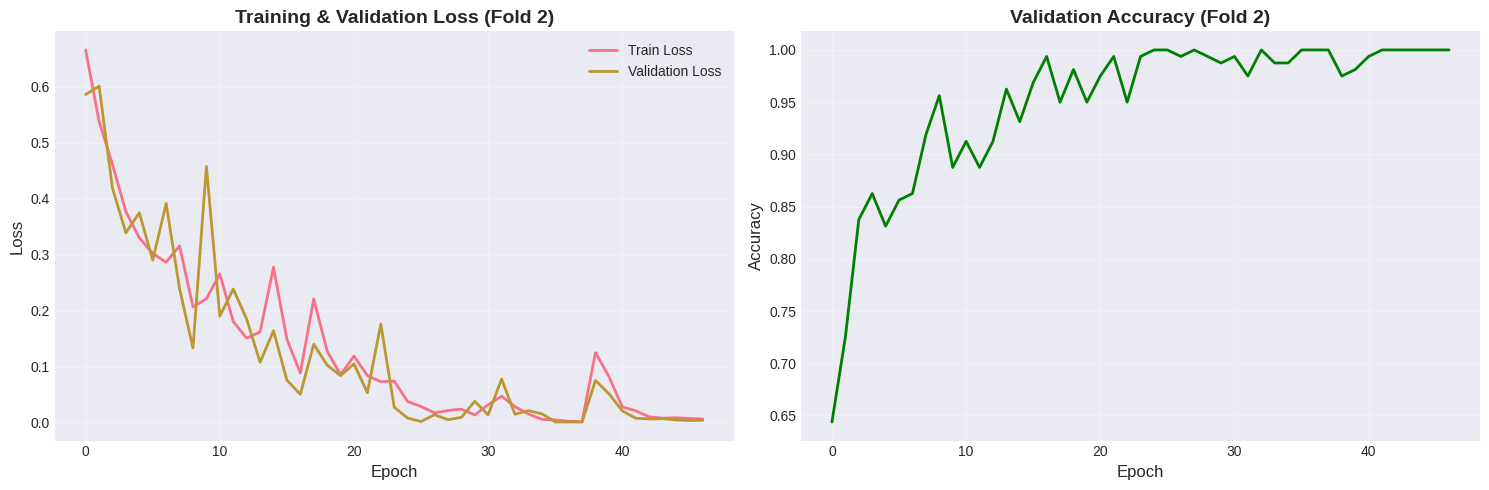

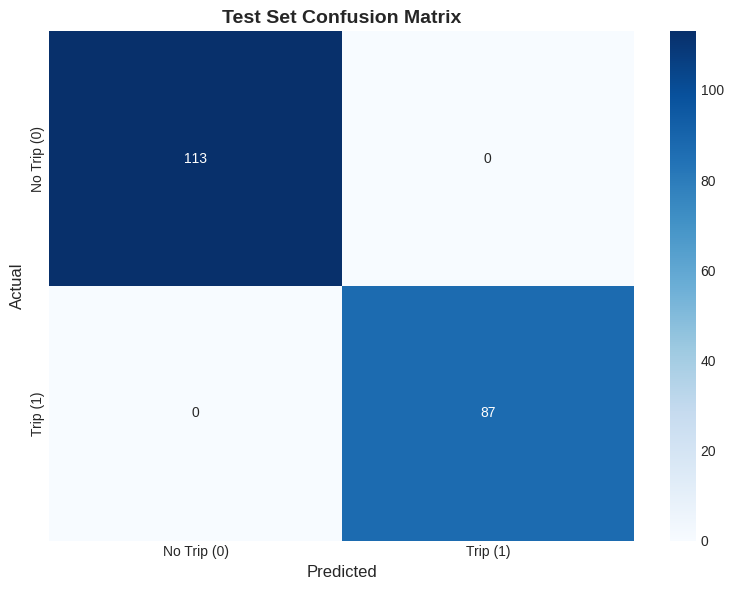

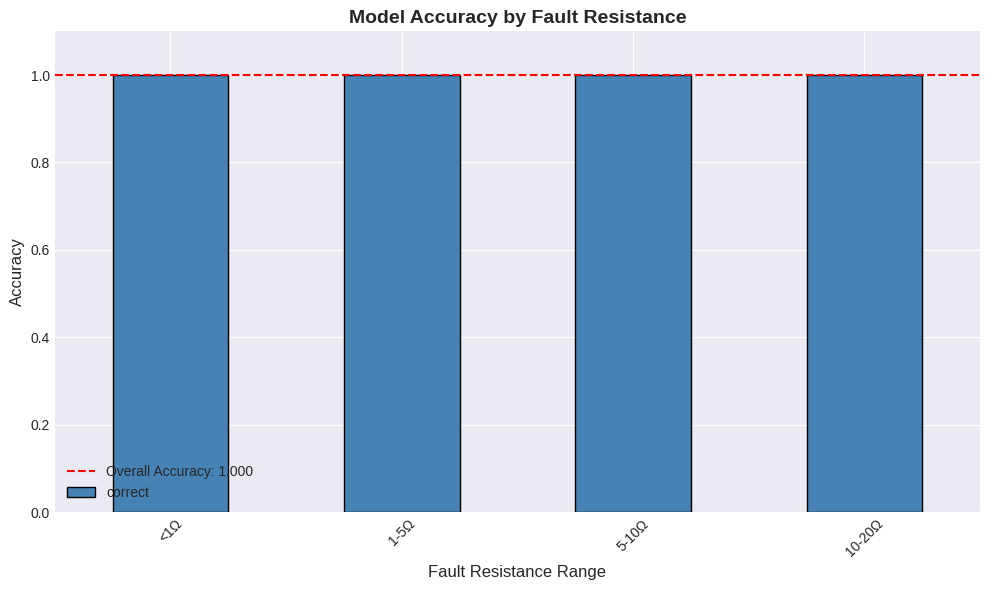

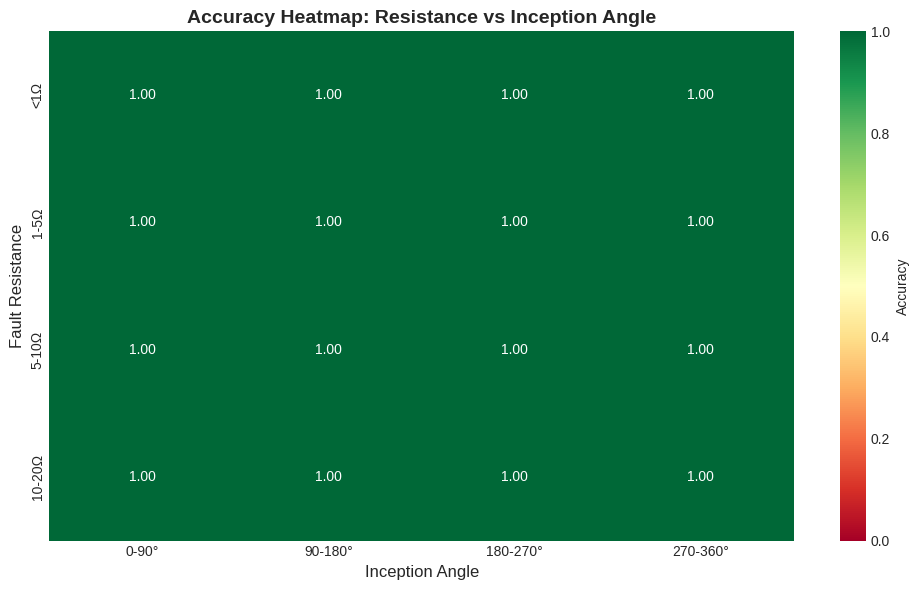

In [ ]:

print("GENERATING VISUALIZATIONS")


# Figure 1: Training Curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

best_result = fold_results[best_fold_idx]

axes[0].plot(best_result['train_losses'], label='Train Loss', linewidth=2)
axes[0].plot(best_result['val_losses'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title(f'Training & Validation Loss (Fold {best_fold_idx+1})', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(best_result['val_accuracies'], linewidth=2, color='green')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title(f'Validation Accuracy (Fold {best_fold_idx+1})', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Figure 2: Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['No Trip (0)', 'Trip (1)'],
            yticklabels=['No Trip (0)', 'Trip (1)'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Test Set Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Figure 3: Performance by Resistance
fig, ax = plt.subplots(figsize=(10, 6))
resistance_acc = df_test.groupby('resistance_bin')['correct'].mean()
resistance_acc.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Fault Resistance Range', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Model Accuracy by Fault Resistance', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1.1])
ax.axhline(y=test_acc, color='r', linestyle='--', label=f'Overall Accuracy: {test_acc:.3f}')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Figure 4: Resistance vs Angle Heatmap
if len(df_test) > 50:
    pivot_table = pd.crosstab(df_test['resistance_bin'], df_test['angle_bin'],
                               values=df_test['correct'], aggfunc='mean')

    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_table, annot=True, fmt='.2f', cmap='RdYlGn',
                vmin=0, vmax=1, cbar_kws={'label': 'Accuracy'})
    plt.xlabel('Inception Angle', fontsize=12)
    plt.ylabel('Fault Resistance', fontsize=12)
    plt.title('Accuracy Heatmap: Resistance vs Inception Angle', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 12. Save Results
Saving the trained model state, the test predictions with their metadata, and a summary of performance metrics.

In [ ]:

import os

# Save model
torch.save({
    'model_state_dict': best_model.state_dict(),
    'model_config': {
        'input_size': INPUT_SIZE,
        'hidden_size': HIDDEN_SIZE,
        'num_layers': NUM_LAYERS,
        'dropout': DROPOUT
    },
    'test_metrics': {
        'accuracy': test_acc,
        'precision': test_prec,
        'recall': test_rec,
        'f1_score': test_f1
    }
}, 'transformer_protection_lstm_best.pth')
print("Model saved: transformer_protection_lstm_best.pth")

# Save test predictions with metadata
df_test.to_csv('test_predictions_with_metadata.csv', index=False)
print("Test predictions saved: test_predictions_with_metadata.csv")

# Save performance summary
performance_summary = {
    'Cross-Validation': {
        'Mean Accuracy': f"{np.mean([r['val_accuracy'] for r in fold_results]):.4f}",
        'Std Accuracy': f"{np.std([r['val_accuracy'] for r in fold_results]):.4f}"
    },
    'Test Set': {
        'Accuracy': f"{test_acc:.4f}",
        'F1-Score': f"{test_f1:.4f}"
    }
}

with open('performance_summary.json', 'w') as f:
    json.dump(performance_summary, f, indent=4)
print("Performance summary saved: performance_summary.json")



print("SAVING RESULTS TO GOOGLE DRIVE")


# Define your Drive path (Update 'Thesis_Project' to your actual folder name)
# Make sure this folder exists!
SAVE_DIR = '/content/drive/MyDrive/XFormer_Thesis/Results/Run_20260126'

# Create the directory if it doesn't exist
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"📂 Saving to: {SAVE_DIR}")

# 1. Save Model
model_path = os.path.join(SAVE_DIR, 'transformer_protection_lstm_best.pth')
torch.save({
    'model_state_dict': best_model.state_dict(),
    'model_config': {
        'input_size': INPUT_SIZE,
        'hidden_size': HIDDEN_SIZE,
        'num_layers': NUM_LAYERS,
        'dropout': DROPOUT
    },
    'test_metrics': {
        'accuracy': test_acc,
        'f1_score': test_f1
    }
}, model_path)
print(f"✅ Model saved")

# 2. Save CSVs and JSONs
df_test.to_csv(os.path.join(SAVE_DIR, 'test_predictions_with_metadata.csv'), index=False)
if len(failures) > 0:
    failures.to_csv(os.path.join(SAVE_DIR, 'failure_analysis.csv'), index=False)

with open(os.path.join(SAVE_DIR, 'performance_summary.json'), 'w') as f:
    json.dump(performance_summary, f, indent=4)



Model saved: transformer_protection_lstm_best.pth
Test predictions saved: test_predictions_with_metadata.csv
Performance summary saved: performance_summary.json
SAVING RESULTS TO GOOGLE DRIVE
📂 Saving to: /content/drive/MyDrive/XFormer_Thesis/Results/Run_20260126
✅ Model saved
✅ All files persisted to Google Drive


## 13. Inference on New Dataset (From External Stress Test)
This section loads the best trained model from **Stress Test Dataset**  and tests it on a completely new, unseen dataset:

STARTING STRESS TEST VALIDATION
   Model: transformer_protection_lstm_best.pth
   Data:  Processed_Stress_Test_With_Metadata.mat

 Loading: /content/drive/MyDrive/XFormer_Thesis/Datasets/Processed_Stress_Test_With_Metadata.mat
   ⚠ MATLAB v7.3 detected, using h5py...
   Debug (h5py): Top-level keys in file: ['#refs#', 'X_LSTM', 'Y_LSTM', 'metadata']
   Debug (h5py): Keys within 'metadata' group: ['faultResistance', 'faultType', 'inceptionAngle', 'shouldTrip', 'stress_CT_Saturation', 'stress_HIF', 'stress_NoiseExtreme', 'zone']
   Debug (h5py): Metadata dictionary keys after load_hdf5_group_recursive: dict_keys(['faultResistance', 'faultType', 'inceptionAngle', 'shouldTrip', 'stress_CT_Saturation', 'stress_HIF', 'stress_NoiseExtreme', 'zone'])
   ✓ Loaded with h5py (MATLAB v7.3 format)
Debug: Type of metadata after load_matlab_data_complete: <class 'dict'>
Debug: Content of metadata after load_matlab_data_complete: dict_keys(['faultResistance', 'faultType', 'inceptionAngle', 'shouldTrip

/tmp/ipython-input-1171854534.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_recall = internal_faults.groupby('res_bin')['correct'].mean()


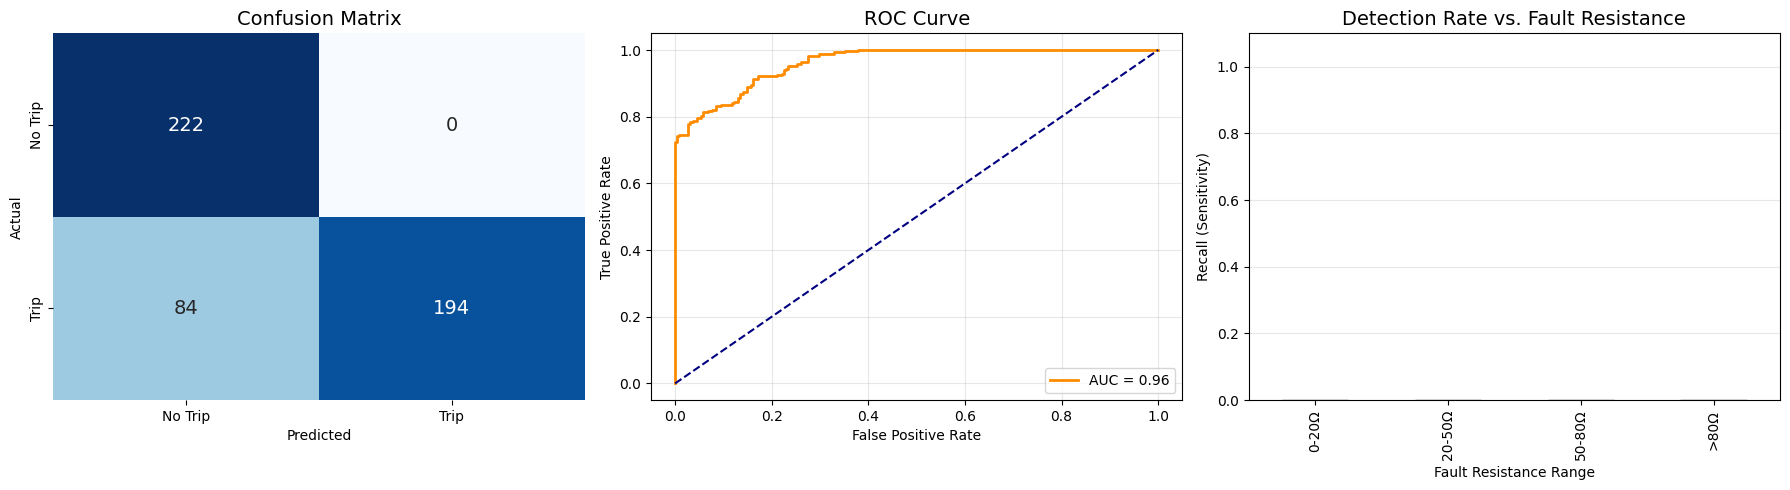

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, auc, classification_report)


# Visualization and Metric Function

def evaluate_and_visualize(y_true, y_pred, y_probs, df_meta=None, save_dir=None):
    """
    Generates performance report, Confusion Matrix, ROC Curve, and Resistance Analysis.
    """
    # --- A. Metrics ---
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    # --- B. Text Report ---
    print("\n" + "="*60)
    print(f"{'EVALUATION REPORT':^60}")
    print("="*60)
    print(f"  Accuracy:      {acc:.4f}")
    print(f"  Precision:     {prec:.4f}  (Security)")
    print(f"  Recall:        {rec:.4f}  (Dependability)")
    print(f"  F1 Score:      {f1:.4f}")
    print("-" * 60)
    print(classification_report(y_true, y_pred, target_names=['No Trip', 'Trip']))
    print("="*60)

    # --- C. Generate Plots ---
    fig = plt.figure(figsize=(18, 5)) # Wider figure for 3 plots

    # Plot 1: Confusion Matrix
    plt.subplot(1, 3, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No Trip', 'Trip'], yticklabels=['No Trip', 'Trip'],
                annot_kws={"size": 14})
    plt.title('Confusion Matrix', fontsize=14)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    # Plot 2: ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.subplot(1, 3, 2)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve', fontsize=14)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)

    # Plot 3: Sensitivity vs. Fault Resistance
    if df_meta is not None:
        plt.subplot(1, 3, 3)

        # Filter for Internal Faults only (we only care about recall here)
        internal_faults = df_meta[df_meta['zone'] == 'Internal'].copy()

        # Create Bins
        internal_faults['res_bin'] = pd.cut(internal_faults['fault_resistance'],
                                          bins=[0, 20, 50, 80, 200],
                                          labels=['0-20Ω', '20-50Ω', '50-80Ω', '>80Ω'])

        # Calculate Recall per bin
        bin_recall = internal_faults.groupby('res_bin')['correct'].mean()

        # Bar Plot
        colors = ['green', 'yellowgreen', 'orange', 'red']
        bin_recall.plot(kind='bar', color=colors, edgecolor='black', alpha=0.7)
        plt.title('Detection Rate vs. Fault Resistance', fontsize=14)
        plt.ylabel('Recall (Sensitivity)')
        plt.xlabel('Fault Resistance Range')
        plt.ylim(0, 1.1)
        plt.grid(axis='y', alpha=0.3)

        # Add values on top of bars
        for i, v in enumerate(bin_recall):
            plt.text(i, v + 0.02, f"{v*100:.1f}%", ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

#Data Loading

def test_external_dataset_enhanced(model_path, new_data_path, device):
    print(f"STARTING STRESS TEST VALIDATION")
    print(f"   Model: {os.path.basename(model_path)}")
    print(f"   Data:  {os.path.basename(new_data_path)}\n")

    # 1. Load Data with flexible unpacking
    try:
        loaded_data = load_matlab_data_complete(new_data_path)

        # Robust Unpacking: Handle 3 or 4 return values
        if len(loaded_data) == 4:
            X_new_raw, Y_new_raw, metadata, _ = loaded_data
        elif len(loaded_data) == 3:
            X_new_raw, Y_new_raw, metadata = loaded_data
        else:
            raise ValueError(f"Unexpected return count: {len(loaded_data)}")

    except Exception as e:
        print(f"❌ Error loading .mat file: {e}")
        return

    # Debug print statement for metadata
    print(f"Debug: Type of metadata after load_matlab_data_complete: {type(metadata)}")
    print(f"Debug: Content of metadata after load_matlab_data_complete: {metadata.keys() if isinstance(metadata, dict) else metadata}")

    # 2. Tensor Conversion
    X_tensor = torch.tensor(X_new_raw).float().permute(2, 1, 0).to(device)
    y_tensor = torch.tensor(Y_new_raw).float().to(device)
    if y_tensor.dim() > 1: y_tensor = y_tensor.squeeze()

    # 3. Load Model
    checkpoint = torch.load(model_path, map_location=device)
    config = checkpoint['model_config']

    # Re-init Model
    model = TransformerProtectionLSTM(
        input_size=config['input_size'],
        hidden_size=config['hidden_size'],
        num_layers=config['num_layers'],
        dropout=config['dropout']
    ).to(device)

    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    # 4. Inference Loop
    dataset = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(dataset, batch_size=32, shuffle=False)

    all_probs = []
    all_preds = []

    with torch.no_grad():
        for X_batch, _ in loader:
            outputs = model(X_batch)
            probs = outputs.cpu().numpy()
            preds = (outputs > 0.5).float().cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(preds)

    # 5. Build Analysis DataFrame
    if metadata:
        # Check if 'faultResistance' needs flattening (sometimes it comes as 2D array)
        res_array = np.array(metadata['faultResistance'])
        if res_array.ndim > 1: res_array = res_array.flatten()

        df_analysis = pd.DataFrame({
            'zone': extract_cell_array(metadata['zone']),
            'fault_resistance': res_array,
            'should_trip': Y_new_raw,
            'prediction': all_preds,
            'correct': (np.array(all_preds) == Y_new_raw)
        })
    else:
        df_analysis = None
        print("⚠ Warning: No metadata found. 'Sensitivity vs Resistance' plot will be skipped.")

    # 6. Visualize
    evaluate_and_visualize(Y_new_raw, all_preds, all_probs, df_analysis)



DRIVE_SAVE_DIR = '/content/drive/MyDrive/XFormer_Thesis/Results/Run_20260126'
MODEL_PATH = os.path.join(DRIVE_SAVE_DIR, 'transformer_protection_lstm_best.pth')

NEW_DATASET_PATH = '/content/drive/MyDrive/XFormer_Thesis/Datasets/Processed_Stress_Test_With_Metadata.mat'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if os.path.exists(MODEL_PATH) and os.path.exists(NEW_DATASET_PATH):
    test_external_dataset_enhanced(MODEL_PATH, NEW_DATASET_PATH, device)
else:
    print(f"❌ File not found.\nChecking Model: {os.path.exists(MODEL_PATH)}\nChecking Data: {os.path.exists(NEW_DATASET_PATH)}")
